# Credit Card Default Prediction
## Deep Learning Challenge 1



Students:

- **Angela Krstevska**

- **Rita Breznica**

- **Dea Nixha**

---
# Part 1: Data Loading & Cleaning

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from joblib import dump
import copy, warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 1.1 Load and Inspect

In [23]:
df = pd.read_excel("default of credit card clients.xls", header=1)
df = df.rename(columns={'default payment next month': 'TARGET'})
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (30000, 25)
Missing values: 0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [24]:
df = df.drop(columns=['ID'])
print(f"Shape: {df.shape}")

Shape: (30000, 24)


Observations:
- 30000 instances, 23 features and 1 target
- There are no missing values
- ID is dropped because it is irrelevant to the prediction

---
# Part 2: Exploratory Data Analysis

## 2.1 Target Distribution

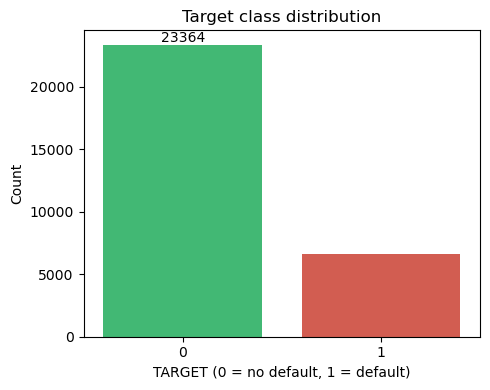

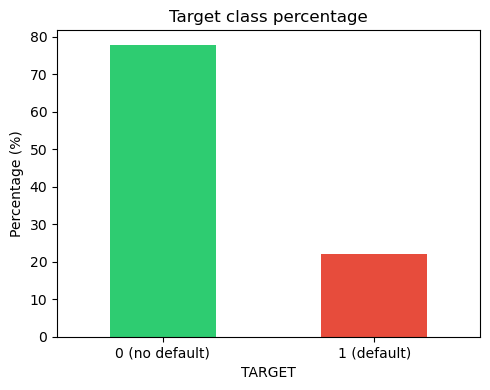

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='TARGET', ax=ax, hue='TARGET', palette=['#2ecc71', '#e74c3c'], legend=False)
ax.bar_label(ax.containers[0])
ax.set_xlabel('TARGET (0 = no default, 1 = default)')
ax.set_ylabel('Count')
ax.set_title('Target class distribution')
plt.tight_layout()
plt.show()

target_pct = df['TARGET'].value_counts(normalize=True).sort_index() * 100
fig, ax = plt.subplots(figsize=(5, 4))
target_pct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], rot=0)
ax.set_ylabel('Percentage (%)')
ax.set_title('Target class percentage')
ax.set_xticklabels(['0 (no default)', '1 (default)'], rotation=0)
plt.tight_layout()
plt.show()


The dataset is imbalanced (approx. 78% no default and approx. 22% default)
This means that:
- We use per-class weights in cross-entropy (computed from training counts in 4.1) so the minority class is not ignored


## 2.2 Categorical features

Counts for **SEX**, **EDUCATION**, and **MARRIAGE** (overall distribution).

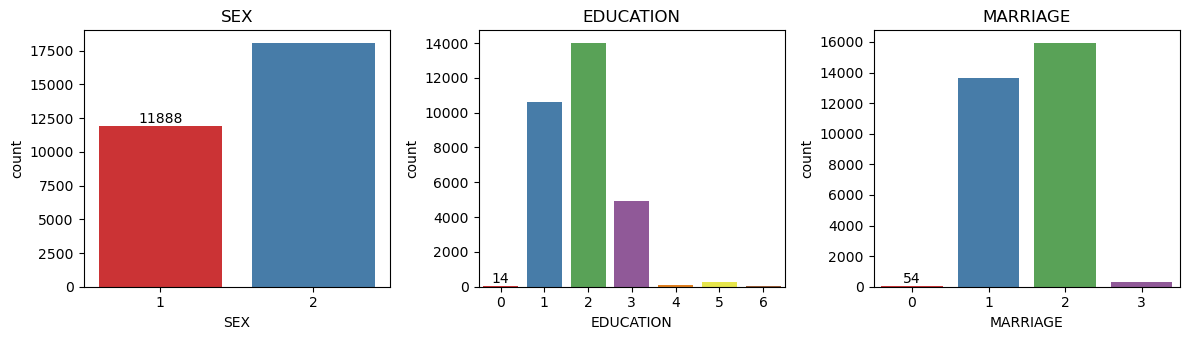

In [26]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, palette='Set1')
    ax.bar_label(ax.containers[0])
    ax.set_title(col)
plt.tight_layout()
plt.show()


Same categorical variables, split by `TARGET`: counts per level for no default (0) vs default (1).


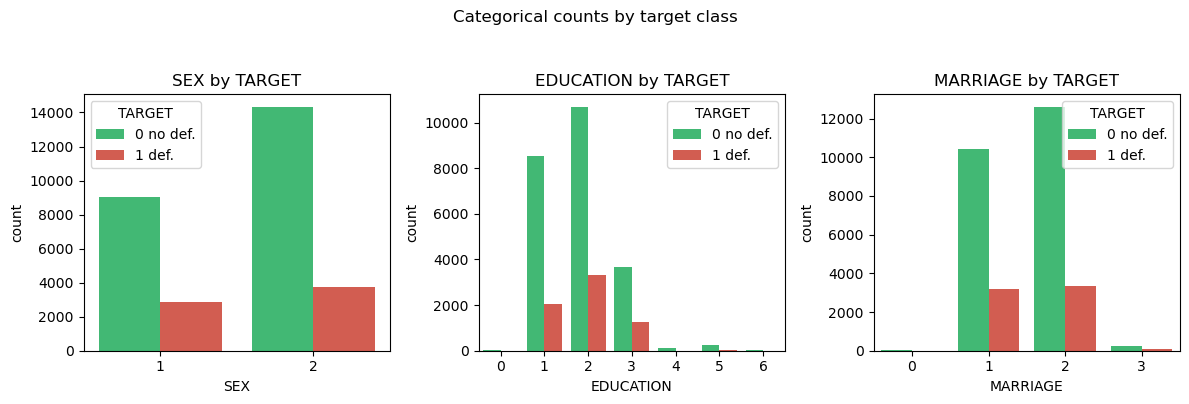

In [27]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='TARGET', ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{col} by TARGET')
    ax.legend(title='TARGET', labels=['0 no def.', '1 def.'])
plt.suptitle('Categorical counts by target class', y=1.05)
plt.tight_layout()
plt.show()


**Vs `TARGET`:** Green (0) is always bigger than red (1) - **imbalanced** data. **Males (1)** show a **slightly larger** share of defaults than **females (2)**. Most people sit in **education 1-3**; **marriage 1 vs 2** looks similar.

**UCI codes:** **SEX** 1/2 = male/female. **EDUCATION** 1-4 defined; **0, 5, 6** rare, need to be merged with 4(other). **MARRIAGE** 1-3 defined; 0 rare, need to be merged with 3(other).


## 2.3 Numerical features


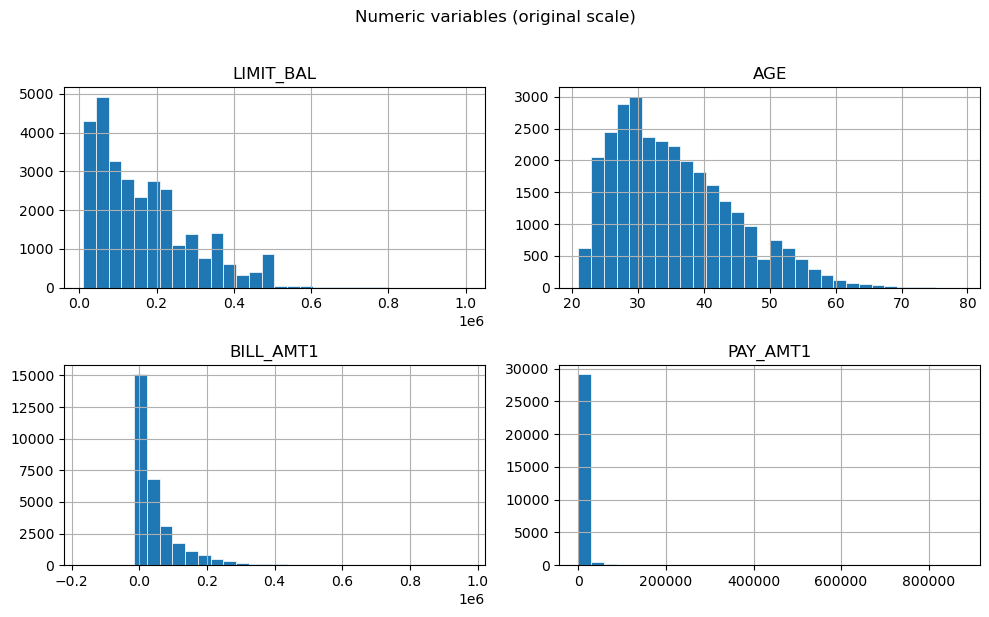

In [28]:
num_examples = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
df[num_examples].hist(figsize=(10, 6), bins=30, edgecolor='white', linewidth=0.5)
plt.suptitle('Numeric variables (original scale)', y=1.02)
plt.tight_layout()
plt.show()


**Same numerical variables, split by `TARGET`:** overlapping histograms (**0** vs **1**) for the four fields above.


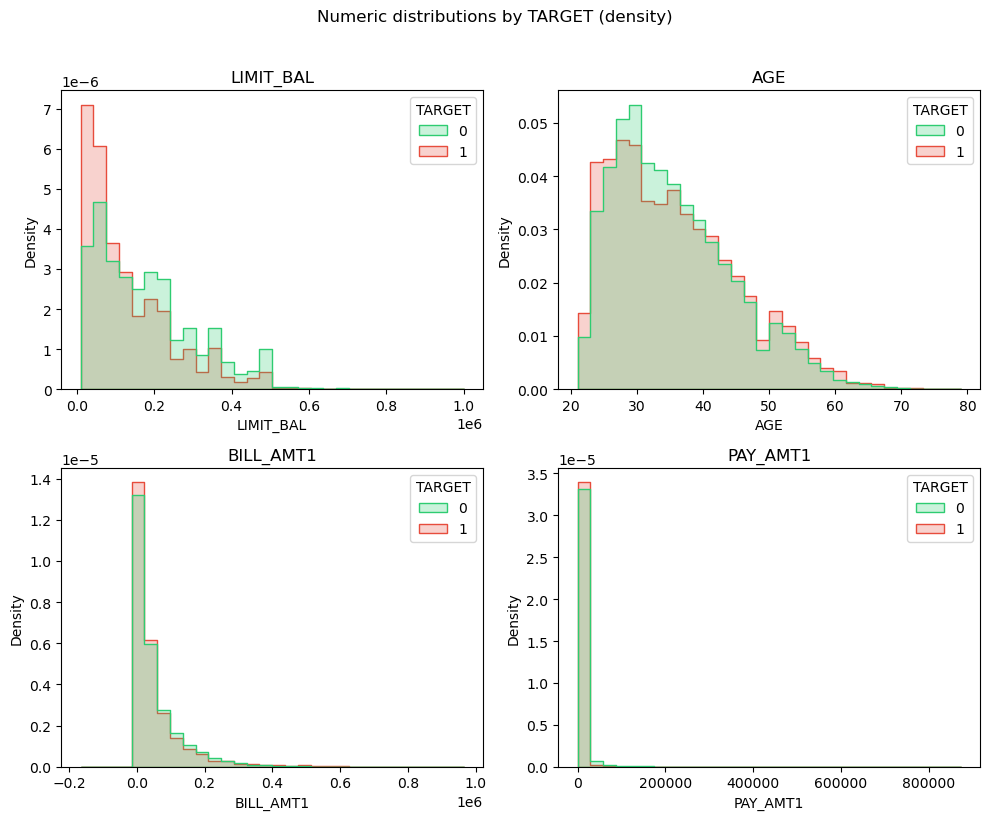

In [29]:
num_examples = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), num_examples):
    sns.histplot(data=df, x=col, hue='TARGET', bins=30, ax=ax, palette=['#2ecc71', '#e74c3c'],
                 element='step', stat='density', common_norm=False)
    ax.set_title(col)
plt.suptitle('Numeric distributions by TARGET (density)', y=1.02)
plt.tight_layout()
plt.show()


Observations:
- All four are **right-skewed**; financial fields pile up near zero with **long tails** (large limits/payments are rare). 
- **`AGE`** is more bell-like, peaking in the 30s. 
- **`BILL_AMT1`** can be negative (credit balance), we only use log1p below on non-negative columns for a clearer picture of skewed amounts.


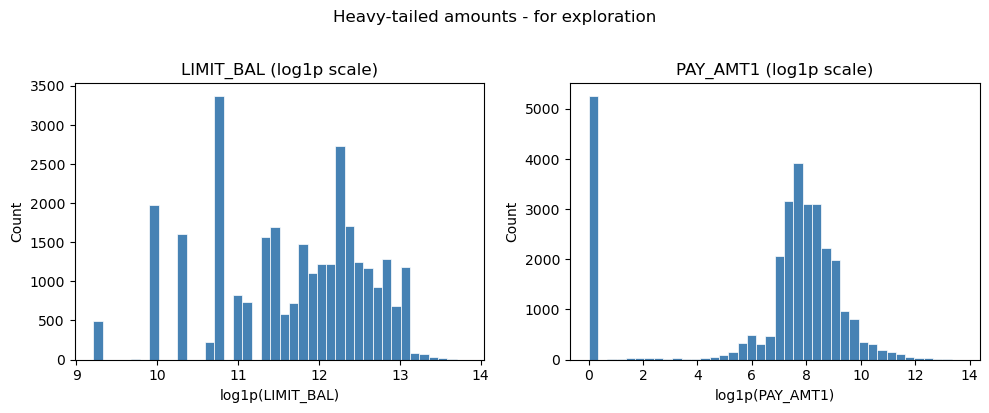

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['LIMIT_BAL', 'PAY_AMT1']):
    ax.hist(np.log1p(df[col]), bins=40, edgecolor='white', linewidth=0.5, color='steelblue')
    ax.set_xlabel(f'log1p({col})')
    ax.set_ylabel('Count')
    ax.set_title(f'{col} (log1p scale)')
plt.suptitle('Heavy-tailed amounts - for exploration', y=1.02)
plt.tight_layout()
plt.show()


**Log-scale plots**

- **`LIMIT_BAL`** has many peaks, limits cluster at **common** credit-line values, not a smooth curve.
- **`PAY_AMT1`** - tall bar at **0** which means **many zero payments**; positive payments spread over a **wide range** (easier to see after `log1p`).



### Monthly series (Apr to Sep 2005)

UCI columns are **six statement months**: `BILL_AMT6`…`BILL_AMT1` = Apr…Sep bill amounts; `PAY_6`…`PAY_0` = Apr…Sep **repayment status** (higher = more delay). Lines = **mean across all customers**


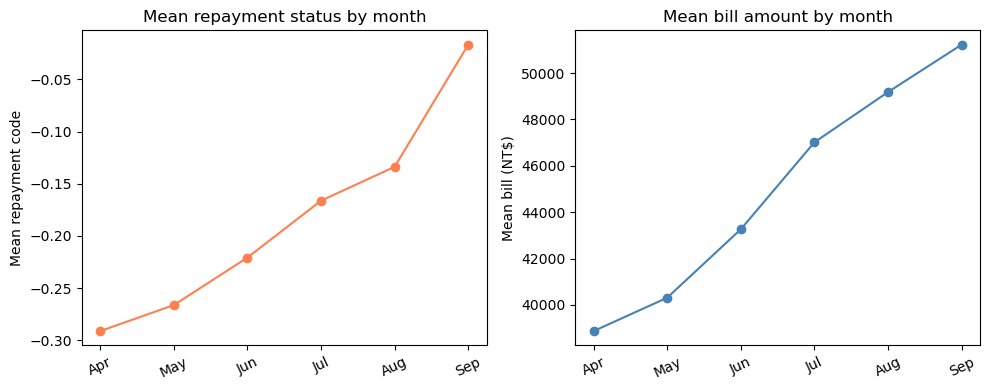

In [31]:
months = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
pay_m = [f'PAY_{i}' for i in [6, 5, 4, 3, 2, 0]]
bill_m = [f'BILL_AMT{i}' for i in [6, 5, 4, 3, 2, 1]]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(months, df[pay_m].mean(), marker='o', color='coral')
axes[0].set_ylabel('Mean repayment code')
axes[0].set_title('Mean repayment status by month')
axes[0].tick_params(axis='x', rotation=25)
axes[1].plot(months, df[bill_m].mean(), marker='o', color='steelblue')
axes[1].set_ylabel('Mean bill (NT$)')
axes[1].set_title('Mean bill amount by month')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


Both lines trend up by month: average bills increase Apr to Sep, and the mean repayment code moves toward zero, consistent with a bit more payment stress alongside higher balances in the recent months.

## 2.4 Correlation matrix 

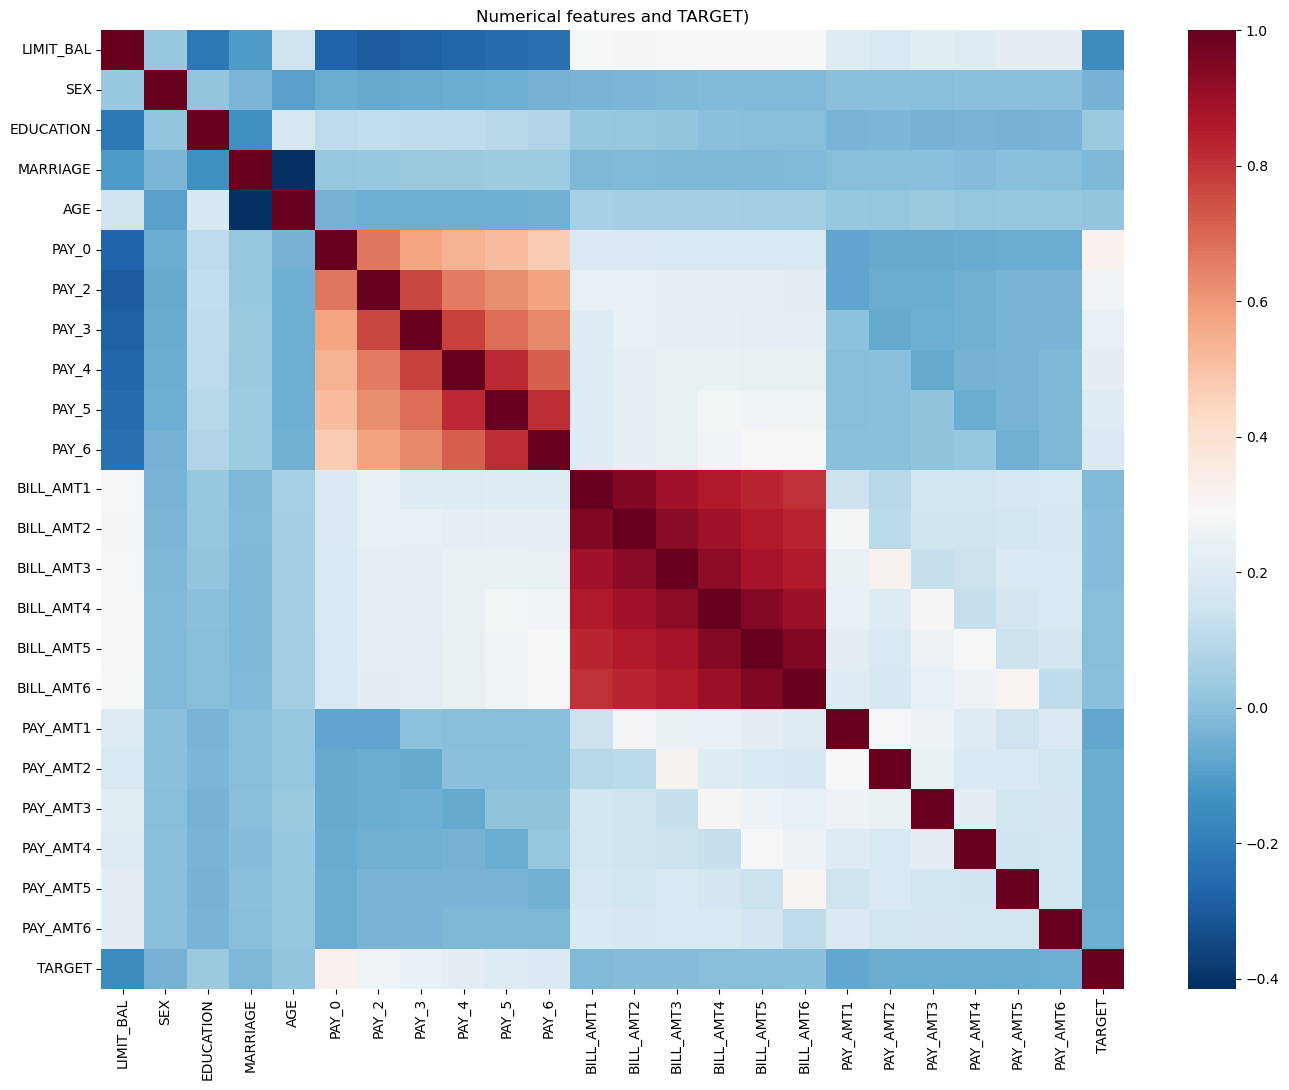

Correlation with TARGET
PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
LIMIT_BAL   -0.154
PAY_AMT1    -0.073
PAY_AMT2    -0.059
PAY_AMT4    -0.057
PAY_AMT3    -0.056
PAY_AMT5    -0.055
PAY_AMT6    -0.053
SEX         -0.040
EDUCATION    0.028
MARRIAGE    -0.024
BILL_AMT1   -0.020
BILL_AMT2   -0.014
BILL_AMT3   -0.014
AGE          0.014
BILL_AMT4   -0.010
BILL_AMT5   -0.007
BILL_AMT6   -0.005


In [32]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='RdBu_r')
plt.title('Numerical features and TARGET)')
plt.tight_layout()
plt.show()

print('Correlation with TARGET')
print(corr['TARGET'].drop('TARGET').reindex(
    corr['TARGET'].drop('TARGET').abs().sort_values(ascending=False).index
).round(3).to_string())



## 2.5 Follow-up: two variables tied to target

**`PAY_0`** has the strongest linear link with default; **`LIMIT_BAL`** has the clearest negative link. Boxplots show **medians and spread** by class 


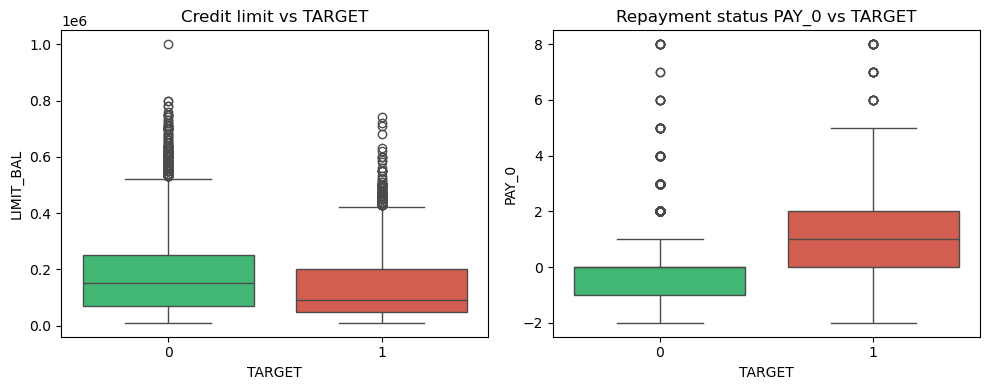

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x='TARGET', y='LIMIT_BAL', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Credit limit vs TARGET')
sns.boxplot(data=df, x='TARGET', y='PAY_0', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Repayment status PAY_0 vs TARGET')
plt.tight_layout()
plt.show()


**Boxplots:** **`LIMIT_BAL`** - median **lower** when **TARGET = 1** (fits negative *r*). **`PAY_0`** - **higher** delay codes when **TARGET = 1** (fits positive *r*). Same story as the correlation list, shown as distributions.


---
# Part 3: Preprocessing

We prepare inputs for a feed-forward network: mixed **continuous** (money, age), **nominal** categories (`SEX`, `EDUCATION`, `MARRIAGE`) and **ordinal** payment codes (`PAY_0`–`PAY_6`).  


## 3.1 Cleaning rare label codes

Map undocumented UCI codes to documented buckets before modelling.


In [34]:
data = df.copy()
# EDUCATION: merge unknown into "others" (4)
data['EDUCATION'] = data['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
# MARRIAGE: merge undocumented 0 into "others" (3)
data['MARRIAGE'] = data['MARRIAGE'].replace({0: 3})
print(data[['SEX', 'EDUCATION', 'MARRIAGE']].nunique())
print('Shape:', data.shape)


SEX          2
EDUCATION    4
MARRIAGE     3
dtype: int64
Shape: (30000, 24)


## 3.1b Engineered features

Five derived features are added to give the model extra signal without adding network parameters.

From **`PAY_0`-`PAY_6`** (ordinal delay codes):
- `AVG_PAY_DELAY` - mean delay code across the six months (overall payment stress)
- `MAX_PAY_DELAY` - maximum delay code (worst month)
- `NUM_LATE` - number of months with code >= 1 (how often the client was late)

From billing and payment amounts:
- `UTIL_RATIO` - `BILL_AMT1 / LIMIT_BAL`, i.e. how much of the credit limit is currently used. Higher values suggest more financial stress.
- `PAY_RATIO` - `PAY_AMT1 / BILL_AMT1`, i.e. how much of the latest bill was repaid. Lower values suggest mostly minimum/partial repayment.


In [35]:
pay_hist = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
data['AVG_PAY_DELAY'] = data[pay_hist].mean(axis=1)
data['MAX_PAY_DELAY'] = data[pay_hist].max(axis=1)
data['NUM_LATE'] = (data[pay_hist] >= 1).sum(axis=1)

data['UTIL_RATIO'] = data['BILL_AMT1'] / (data['LIMIT_BAL'].abs() + 1e-8)
data['PAY_RATIO']  = data['PAY_AMT1'] / (data['BILL_AMT1'].abs() + 1e-8)

eng_features = ['AVG_PAY_DELAY', 'MAX_PAY_DELAY', 'NUM_LATE', 'UTIL_RATIO', 'PAY_RATIO']
print(data[eng_features].describe().round(3))


       AVG_PAY_DELAY  MAX_PAY_DELAY   NUM_LATE  UTIL_RATIO     PAY_RATIO
count      30000.000      30000.000  30000.000   30000.000  3.000000e+04
mean          -0.182          0.439      0.834       0.424  9.475267e+09
std            0.982          1.345      1.554       0.411  2.689602e+11
min           -2.000         -2.000      0.000      -0.620  0.000000e+00
25%           -0.833          0.000      0.000       0.022  3.500000e-02
50%            0.000          0.000      0.000       0.314  5.700000e-02
75%            0.000          2.000      1.000       0.830  2.940000e-01
max            6.000          8.000      6.000       6.455  2.988870e+13


## 3.2 Train / validation / test split
A stratified split on `TARGET` keeps train, validation, and test with similar default rates. All preprocessing is fit on train only, then applied to val/test (no leakage).


In [ ]:
from sklearn.model_selection import train_test_split

y = data['TARGET'].astype(np.float32)
X_raw = data.drop(columns=['TARGET'])

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.17647059, stratify=y_temp, random_state=RANDOM_STATE
)
# ~70% / 15% / 15%
print('Train', X_train.shape[0], 'Val', X_val.shape[0], 'Test', X_test.shape[0])


Train 20999 Val 4501 Test 4500


## 3.3 Encoding: nominal vs continuous / ordinal

- Nominal features (`SEX`, `EDUCATION`, `MARRIAGE`) are one-hot encoded with `pandas.get_dummies`, so each category becomes its own 0/1 column.
- All other columns stay numeric. This includes ordinal `PAY_0`-`PAY_6` (where order matters) and continuous variables (amounts, age, credit limit).

As discussed in the lectures, bipolar encoding (-1/+1) implies distances between categories. That is not appropriate for nominal variables like SEX, EDUCATION, and MARRIAGE, because they have no true ordering. One-hot encoding avoids adding fake order. For ordinal PAY delay codes, numeric values are kept because their ranking is meaningful (1-month delay < 2-month delay < ...).


In [37]:
nominal = ['SEX', 'EDUCATION', 'MARRIAGE']
num_cols = [c for c in X_train.columns if c not in nominal]

def encode_split(X_df):
    d = pd.get_dummies(X_df[nominal], columns=nominal, drop_first=False)
    X_num = X_df[num_cols].astype(np.float32)
    return pd.concat([X_num.reset_index(drop=True), d.reset_index(drop=True)], axis=1)

X_train_e = encode_split(X_train)
X_val_e = encode_split(X_val)
X_test_e = encode_split(X_test)

feature_cols = X_train_e.columns.tolist()
X_val_e = X_val_e.reindex(columns=feature_cols, fill_value=0)
X_test_e = X_test_e.reindex(columns=feature_cols, fill_value=0)

print('Encoded feature dim:', len(feature_cols))


Encoded feature dim: 34


## 3.4 Standardize (fit on training set only)

`StandardScaler` (zero mean, unit variance per column) is fit only on `X_train`, then the same transform is applied to val/test. This keeps large monetary features from dominating optimization.


In [38]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_e)
X_val_s = scaler.transform(X_val_e)
X_test_s = scaler.transform(X_test_e)
print(X_train_s.shape)


(20999, 34)


## 3.5 Class imbalance

The training labels are imbalanced (~78% class 0). In Section 4.1, class weights are computed from training counts only and used in `CrossEntropyLoss` (not on val/test).


In [39]:
n_class0 = (y_train.values == 0).sum()
n_class1 = (y_train.values == 1).sum()
print(f"Training class counts — 0: {n_class0}, 1: {n_class1}")


Training class counts — 0: 16354, 1: 4645


## 3.6 PyTorch tensors

All splits are converted into PyTorch tensors and moved to the selected device.


In [40]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32, device=device).unsqueeze(1)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32, device=device).unsqueeze(1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32, device=device).unsqueeze(1)
print(X_train_t.shape, y_train_t.shape)


torch.Size([20999, 34]) torch.Size([20999, 1])


---
# Part 4: Evaluation (competition F1)

This section compares model variants using macro F1, which is the competition metric.

In [41]:
from sklearn.metrics import f1_score
import torch

def calculate_f1_score(model, dataloader, device):
    """
    Standardized evaluation for the MSc Deep Learning Competition.
    Uses 'macro' averaging to ensure fairness across imbalanced classes.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Get the index of the highest prediction
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # The 'macro' setting is the key for the competition ranking
    score = f1_score(all_labels, all_preds, average='macro')
    return score


## 4.1 Base model (lecture default)

The base model is a feed-forward MLP with hidden blocks (default: 2), each in the form **Linear -> BatchNorm -> Activation**. If `dropout > 0`, dropout is added after each activation. The output layer returns two logits, and `calculate_f1_score` applies argmax over logits with shape `(batch, 2)`.

`CreditDefaultMLP` also supports `hidden_depth` (e.g. 3 hidden blocks at the same width) and `dropout` (e.g. 0.2), while keeping baseline behavior when not specified.

- **Hidden width:** approximately `(INPUT_DIM + 2) / 2`, rounded (lecture rule of thumb).
- **Hidden activation:** ReLU by default. Experiment 2 tests ELU and SELU with lecture-style initialization (He for ELU, LeCun normal with variance `1/fan_in` for SELU).
- **Loss:** `CrossEntropyLoss` with class weights computed from training labels only (balanced weighting).
- **Training labels:** integer class indices 0 and 1, shape `(N,)`.


In [77]:
INPUT_DIM = X_train_t.shape[1]
HIDDEN = max(16, (INPUT_DIM + 2) // 2)  # lecture rule: ~(input + output) / 2, output = 2 classes


class CreditDefaultMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=None, activation="relu",
                 hidden_depth=2, dropout=0.0):
        super().__init__()
        if hidden_dim is None:
            hidden_dim = max(16, (input_dim + 2) // 2)

        act_map = {"relu": nn.ReLU, "elu": nn.ELU, "selu": nn.SELU}
        act_cls = act_map[activation.lower()]

        layers = []
        in_f = input_dim
        for _ in range(hidden_depth):
            layers.extend([nn.Linear(in_f, hidden_dim), nn.BatchNorm1d(hidden_dim), act_cls()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_f = hidden_dim
        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)

        # Lecture init: He for ELU, LeCun for SELU, default for ReLU
        if activation.lower() != "relu":
            for m in self.net.modules():
                if isinstance(m, nn.Linear):
                    if activation.lower() == "selu":
                        nn.init.normal_(m.weight, std=(1.0 / m.in_features) ** 0.5)
                    else:
                        nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# Balanced class weights: w_i = N / (K * count_i)
y_int = y_train.values.astype(np.int64)
counts = np.bincount(y_int, minlength=2)
ce_weight = torch.tensor(len(y_int) / (2 * counts), dtype=torch.float32, device=device)

y_train_long = y_train_t.long().view(-1)
y_val_long = y_val_t.long().view(-1)
y_test_long = y_test_t.long().view(-1)

base_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=HIDDEN).to(device)
n_params = sum(p.numel() for p in base_model.parameters())

print(f"INPUT_DIM={INPUT_DIM}, HIDDEN={HIDDEN}")
print(f"Parameters: {n_params:,}")
print(f"ce_weight (classes 0, 1): {ce_weight.cpu().tolist()}")


def train_credit_mlp(name, model, *, lr=1e-3, weight_decay=0.0,
                     batch_size=32, max_epochs=100, patience=15):
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_long),
                              batch_size=batch_size, shuffle=True,
                              generator=torch.Generator().manual_seed(RANDOM_STATE))
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_long), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_long), batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss(weight=ce_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    train_losses, val_losses = [], []
    best_val, best_state, epochs_no_improve = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        total, n = 0.0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item() * xb.size(0)
            n += xb.size(0)
        tr_loss = total / n

        model.eval()
        with torch.no_grad():
            total, n = 0.0, 0
            for xb, yb in val_loader:
                loss = criterion(model(xb), yb)
                total += loss.item() * xb.size(0)
                n += xb.size(0)
        va_loss = total / n

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        scheduler.step(va_loss)

        if va_loss < best_val - 1e-6:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch == 1 or epoch % 5 == 0:
            print(f"Epoch {epoch:3d}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}")

        if epochs_no_improve >= patience:
            print(f"{name} early stop epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    val_f1 = calculate_f1_score(model, val_loader, device)
    test_f1 = calculate_f1_score(model, test_loader, device)
    print(f"{name}  best_val_loss={best_val:.4f}  val_macro_F1={val_f1:.4f}  test_macro_F1={test_f1:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_losses, label="train")
    ax.plot(val_losses, label="val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(name)
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    return {"name": name, "best_val_loss": best_val, "val_macro_f1": val_f1,
            "test_macro_f1": test_f1, "train_losses": train_losses, "val_losses": val_losses}


def train_credit_mlp_onecycle(name, model, *, max_lr=1e-2, epochs=50, batch_size=32,
                              weight_decay=0.0, pct_start=0.3, div_factor=10.0,
                              final_div_factor=1e4):
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_long),
                              batch_size=batch_size, shuffle=True,
                              generator=torch.Generator().manual_seed(RANDOM_STATE))
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_long), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_long), batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss(weight=ce_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=max_lr / div_factor, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=max_lr, epochs=epochs, steps_per_epoch=len(train_loader),
        pct_start=pct_start, div_factor=div_factor, final_div_factor=final_div_factor)

    train_losses, val_losses = [], []
    best_val, best_state = float("inf"), None

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss, total_n = 0.0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)
        tr_loss = epoch_loss / total_n

        model.eval()
        with torch.no_grad():
            total, n = 0.0, 0
            for xb, yb in val_loader:
                loss = criterion(model(xb), yb)
                total += loss.item() * xb.size(0)
                n += xb.size(0)
        va_loss = total / n

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        if va_loss < best_val - 1e-6:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    val_f1 = calculate_f1_score(model, val_loader, device)
    test_f1 = calculate_f1_score(model, test_loader, device)
    print(f"{name}  best_val_loss={best_val:.4f}  val_macro_F1={val_f1:.4f}  test_macro_F1={test_f1:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_losses, label="train")
    ax.plot(val_losses, label="val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(name)
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    return {"name": name, "best_val_loss": best_val, "val_macro_f1": val_f1,
            "test_macro_f1": test_f1, "train_losses": train_losses, "val_losses": val_losses}

INPUT_DIM=34, HIDDEN=18
Parameters: 1,082
ce_weight (classes 0, 1): [0.64201420545578, 2.260387420654297]


## 4.2 Training (baseline run)

### Baseline hyperparameter choice

- `lr=1e-3`: standard Adam default; usually stable and fast enough. `ReduceLROnPlateau` halves LR when val loss stalls.
- `batch_size=32`: practical balance of gradient stability/noise and memory.
- `patience=15`: early stopping restores the best checkpoint to limit overfitting.
- Adam: adaptive per-parameter steps with momentum-like behavior.

Training uses mini-batch Adam with `CrossEntropyLoss(weight=ce_weight)`. Per epoch: track train/val loss, plot both curves, and report macro F1 on validation plus one held-out test evaluation (`calculate_f1_score`).


Epoch   1  train_loss=0.5951  val_loss=0.5713  lr=1.00e-03
Epoch   5  train_loss=0.5672  val_loss=0.5637  lr=1.00e-03
Epoch  10  train_loss=0.5611  val_loss=0.5551  lr=1.00e-03
Epoch  15  train_loss=0.5573  val_loss=0.5529  lr=1.00e-03
Epoch  20  train_loss=0.5539  val_loss=0.5630  lr=1.00e-03
Epoch  25  train_loss=0.5480  val_loss=0.5602  lr=5.00e-04
Epoch  30  train_loss=0.5472  val_loss=0.5555  lr=2.50e-04
baseline early stop epoch 30
baseline  best_val_loss=0.5529  val_macro_F1=0.7008  test_macro_F1=0.6836


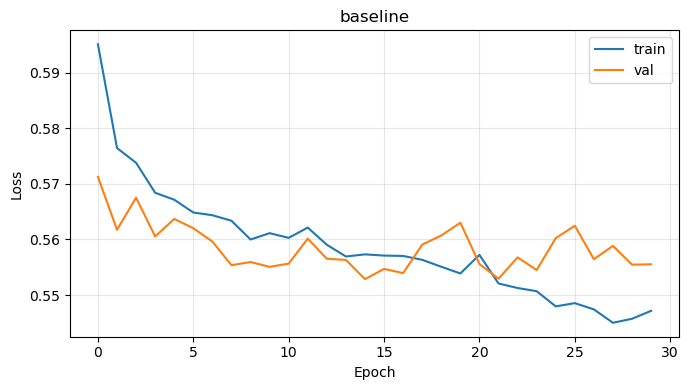

In [68]:
baseline_result = train_credit_mlp("baseline", base_model)

### Baseline run

With engineered features, `INPUT_DIM=34`, so baseline hidden width is 18.

- Early stop at epoch 30; **1,082 parameters**.
- Validation macro F1: **0.7008**; test macro F1: **0.6836**.
- Train loss keeps dropping while validation loss flattens then worsens (even after LR reduction), indicating early overfitting.


## 4.3 Experiments


---

### Experiment 1: Wider hidden layer

The baseline train-val gap could mean either limited capacity or overfitting.

So hidden width is increased from 18 to 64 (same training setup). If validation F1 rises, capacity was limiting; if it drops, overfitting likely dominates. Train-val curves and test F1 are both used for interpretation.


wider_hidden_64: parameters=6786
Epoch   1  train_loss=0.5854  val_loss=0.5796  lr=1.00e-03
Epoch   5  train_loss=0.5642  val_loss=0.5669  lr=1.00e-03
Epoch  10  train_loss=0.5546  val_loss=0.5637  lr=1.00e-03
Epoch  15  train_loss=0.5415  val_loss=0.5634  lr=5.00e-04
Epoch  20  train_loss=0.5359  val_loss=0.5776  lr=2.50e-04
wider_hidden_64 early stop epoch 23
wider_hidden_64  best_val_loss=0.5585  val_macro_F1=0.7067  test_macro_F1=0.6853


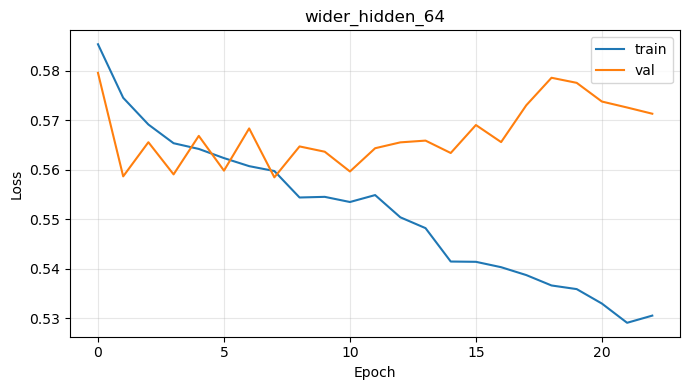

In [69]:
# Experiment 1 — wider hidden layer
torch.manual_seed(RANDOM_STATE)
exp_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=64).to(device)
print(f"wider_hidden_64: parameters={sum(p.numel() for p in exp_model.parameters())}")

exp1_result = train_credit_mlp("wider_hidden_64", exp_model)

### Experiment 1 - Findings

- **6,786 parameters**, early stop at epoch 23. Validation F1: **0.7067**, test F1: **0.6853**.
- Going wider improves validation F1 over baseline (0.7067 vs 0.7008); test F1 also improves slightly (0.6853 vs 0.6836).
- The train-val gap remains (train decreases, validation plateaus/worsens), so overfitting risk is still present.

**Best so far (validation macro F1): wider64.** Next: controlled activation test, then dropout on the wide model.


### Experiment 2: Activation functions (ELU vs SELU)

**Best validation F1 so far:** wider64 (**0.7067**). To isolate effect, architecture stays baseline-sized (18 hidden units, 1,082 params), and only activation is changed.

Goal: check whether ELU/SELU beats baseline ReLU before adding regularization.

- **ELU:** nonzero gradient for negative inputs; mean closer to zero. Uses **He initialization**.
- **SELU:** self-normalizing option; tested under the expected conditions (dense net, standardized inputs, **LeCun initialization** with variance `1/fan_in`).


elu_act_h17: parameters=1082
Epoch   1  train_loss=0.6145  val_loss=0.5958  lr=1.00e-03
Epoch   5  train_loss=0.5771  val_loss=0.5650  lr=1.00e-03
Epoch  10  train_loss=0.5690  val_loss=0.5597  lr=1.00e-03
Epoch  15  train_loss=0.5653  val_loss=0.5580  lr=1.00e-03
Epoch  20  train_loss=0.5638  val_loss=0.5650  lr=1.00e-03
Epoch  25  train_loss=0.5609  val_loss=0.5629  lr=1.00e-03
Epoch  30  train_loss=0.5611  val_loss=0.5551  lr=1.00e-03
Epoch  35  train_loss=0.5585  val_loss=0.5567  lr=5.00e-04
Epoch  40  train_loss=0.5555  val_loss=0.5606  lr=5.00e-04
elu_act_h17 early stop epoch 44
elu_act_h17  best_val_loss=0.5545  val_macro_F1=0.6952  test_macro_F1=0.6821


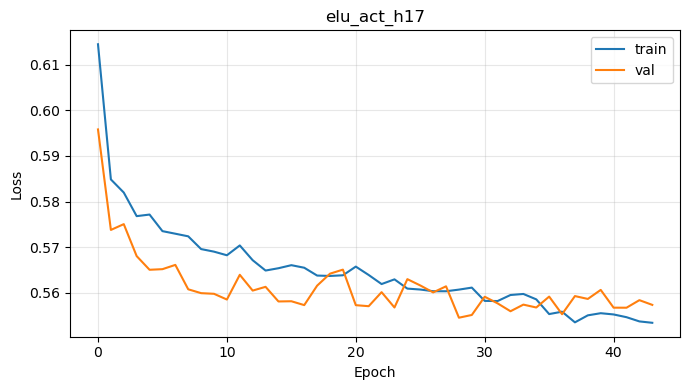

In [70]:
# Experiment 2a — ELU (He init), same width as baseline
torch.manual_seed(RANDOM_STATE)
exp_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=HIDDEN, activation="elu").to(device)
print(f"elu_act_h17: parameters={sum(p.
      numel() for p in exp_model.parameters())}")

exp3a_result = train_credit_mlp("elu_act_h17", exp_model)

selu_act_h17: parameters=1082
Epoch   1  train_loss=0.6052  val_loss=0.5946  lr=1.00e-03
Epoch   5  train_loss=0.5777  val_loss=0.5670  lr=1.00e-03
Epoch  10  train_loss=0.5689  val_loss=0.5626  lr=1.00e-03
Epoch  15  train_loss=0.5656  val_loss=0.5591  lr=1.00e-03
Epoch  20  train_loss=0.5638  val_loss=0.5638  lr=1.00e-03
Epoch  25  train_loss=0.5610  val_loss=0.5634  lr=1.00e-03
Epoch  30  train_loss=0.5602  val_loss=0.5545  lr=1.00e-03
Epoch  35  train_loss=0.5584  val_loss=0.5584  lr=5.00e-04
Epoch  40  train_loss=0.5556  val_loss=0.5587  lr=5.00e-04
selu_act_h17 early stop epoch 44
selu_act_h17  best_val_loss=0.5541  val_macro_F1=0.6975  test_macro_F1=0.6868


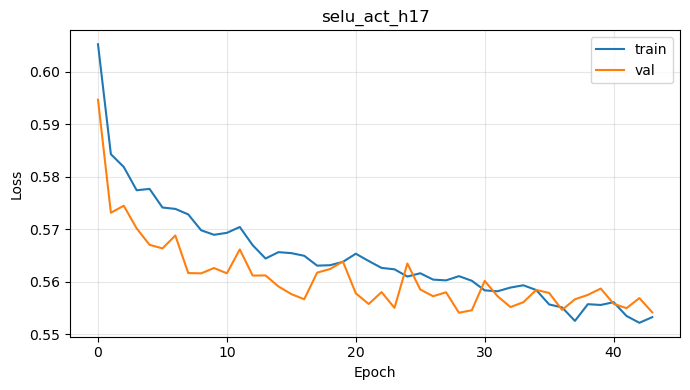

In [71]:
# Experiment 2b — SELU (LeCun init per lecture table), same width as baseline
torch.manual_seed(RANDOM_STATE)
exp_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=HIDDEN, activation="selu").to(device)
print(f"selu_act_h17: parameters={sum(p.numel() for p in exp_model.parameters())}")

exp3b_result = train_credit_mlp("selu_act_h17", exp_model)

### Experiment 2 - Findings

- **ELU:** validation F1 **0.6952**, test F1 **0.6821** (below baseline on both).
- **SELU:** validation F1 **0.6975**, test F1 **0.6868** (validation still below baseline).
- Both runs show a similar gradual train-val gap.

Neither ELU nor SELU beats baseline ReLU on **validation** F1 in this setup (likely because BatchNorm already provides part of SELU’s stabilization effect). **ReLU** is kept.

**Best so far (validation macro F1): still wider64.** Next: dropout on the wide architecture.


---

### Experiment 3: Dropout regularization on the wider network

**Best validation F1 so far:** wider64 (**0.7067**), but with a concerning train-val gap.

Since Experiment 2 did not improve validation F1 via activation changes, the next lever is **regularization** on the wide model.

Dropout (commonly used in the 10%-50% range) is tested on wider64 with two variants:

1. **`wider64_depth3`** - three hidden blocks at width 64 (higher capacity).
2. **`wider64_drop02`** - **dropout 0.2** after each hidden activation.



=== wider64_depth3  params=11074 ===
Epoch   1  train_loss=0.5844  val_loss=0.5781  lr=1.00e-03
Epoch   5  train_loss=0.5651  val_loss=0.5659  lr=1.00e-03
Epoch  10  train_loss=0.5547  val_loss=0.5598  lr=1.00e-03
Epoch  15  train_loss=0.5461  val_loss=0.5637  lr=1.00e-03
Epoch  20  train_loss=0.5304  val_loss=0.5812  lr=5.00e-04
Epoch  25  train_loss=0.5223  val_loss=0.5828  lr=2.50e-04
wider64_depth3 early stop epoch 26
wider64_depth3  best_val_loss=0.5545  val_macro_F1=0.6895  test_macro_F1=0.6848


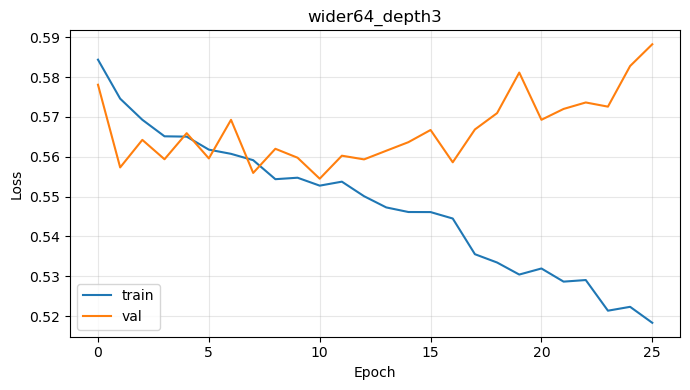


=== wider64_drop02  params=6786 ===
Epoch   1  train_loss=0.5961  val_loss=0.5798  lr=1.00e-03
Epoch   5  train_loss=0.5763  val_loss=0.5617  lr=1.00e-03
Epoch  10  train_loss=0.5670  val_loss=0.5552  lr=1.00e-03
Epoch  15  train_loss=0.5635  val_loss=0.5600  lr=1.00e-03
Epoch  20  train_loss=0.5564  val_loss=0.5686  lr=5.00e-04
Epoch  25  train_loss=0.5539  val_loss=0.5599  lr=2.50e-04
Epoch  30  train_loss=0.5522  val_loss=0.5561  lr=1.25e-04
wider64_drop02 early stop epoch 32
wider64_drop02  best_val_loss=0.5549  val_macro_F1=0.7007  test_macro_F1=0.6873


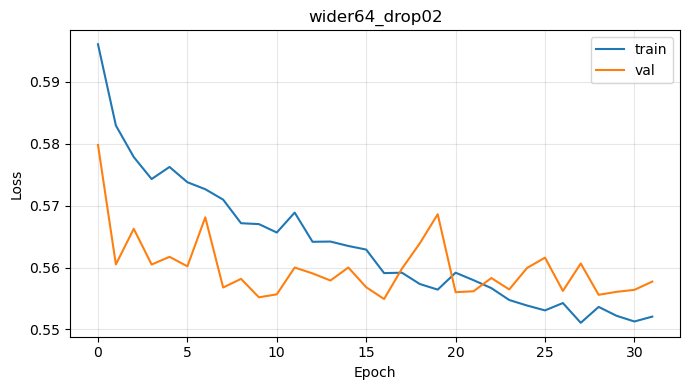

In [72]:
# Experiment 3 — wider 64: depth vs dropout
exp3_runs = [
    ("wider64_depth3", {"hidden_depth": 3}),
    ("wider64_drop02", {"dropout": 0.2}),
]

exp3_results = []
for name, kw in exp3_runs:
    torch.manual_seed(RANDOM_STATE)
    exp_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=64, **kw).to(device)
    print(f"\n=== {name}  params={sum(p.numel() for p in exp_model.parameters())} ===")
    r = train_credit_mlp(name, exp_model)
    exp3_results.append(r)

### Experiment 3 - Findings

- **wider64_depth3** (3 layers, no dropout, 11,074 params): validation F1 **0.6895**, test **0.6848**. Validation worsens after ~epoch 10 while train keeps dropping, indicating overfitting.
- **wider64_drop02** (2 layers, dropout 0.2, 6,786 params): validation F1 **0.7007**, test **0.6873**. Train/validation curves are much closer.

Depth alone hurts; dropout helps.

**Best model so far: wider64_drop02.** Next: OneCycleLR.


### Experiment 4: OneCycleLR and L2 regularization

**Best model so far: wider64_drop02.**

Previous runs used **ReduceLROnPlateau**. Here, **OneCycleLR** is tested (low -> peak -> decay schedule).

Two variants are compared:

1. **4a:** wider64 + dropout 0.2 + OneCycleLR (`epochs=50`, `max_lr=1e-2`, `div_factor=10`, `pct_start=0.3`).
2. **4b:** smaller net (`hidden_dim=32`) + dropout 0.2 + **weight decay `1e-4`**. First tried with 4a-style schedule (`epochs=50`, `max_lr=1e-2`, `pct_start=0.3`), but looked under-trained; extending with same peak LR hurt test F1. Final tuned choice: **`epochs=100`**, **`max_lr=8e-3`**, **`pct_start=0.25`** (gentler, longer cycle).


wider64_drop02_1cycle: parameters=6,786
wider64_drop02_1cycle  best_val_loss=0.5537  val_macro_F1=0.7075  test_macro_F1=0.7000


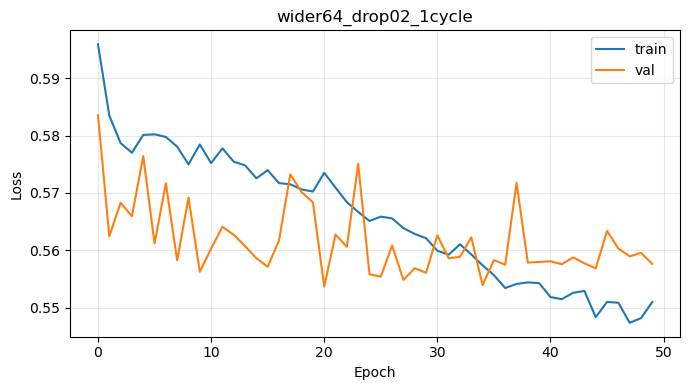

In [73]:
# Experiment 4a — OneCycleLR (same net as wider64_drop02)
torch.manual_seed(RANDOM_STATE)
exp_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=64, dropout=0.2).to(device)
print(f"wider64_drop02_1cycle: parameters={sum(p.numel() for p in exp_model.parameters()):,}")

onecycle_result = train_credit_mlp_onecycle("wider64_drop02_1cycle", exp_model)



narrow32_drop02_1cycle_wd_e100: parameters=2,370
narrow32_drop02_1cycle_wd_e100  best_val_loss=0.5520  val_macro_F1=0.7055  test_macro_F1=0.6968


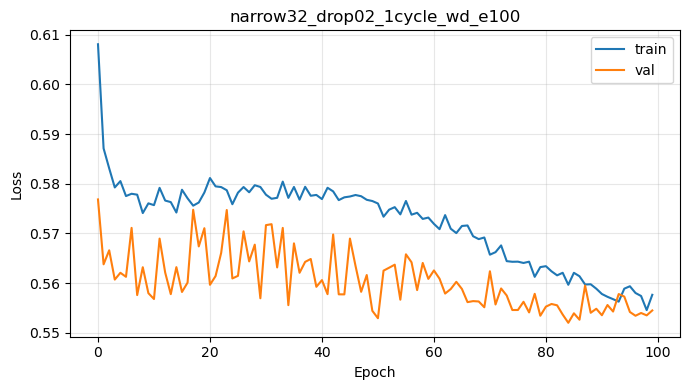

In [ ]:
# Experiment 4b — narrow32 + weight decay + OneCycleLR (tuned longer budget)
torch.manual_seed(RANDOM_STATE)
exp_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=32, dropout=0.2).to(device)
EXP4B_EPOCHS = 100
EXP4B_MAX_LR = 8e-3
EXP4B_PCT_START = 0.25
name_4b = f"narrow32_drop02_1cycle_wd_e{EXP4B_EPOCHS}"
print(f"{name_4b}: parameters={sum(p.numel() for p in exp_model.parameters()):,}")

onecycle_wd_result = train_credit_mlp_onecycle(
    name_4b,
    exp_model,
    epochs=EXP4B_EPOCHS,
    max_lr=EXP4B_MAX_LR,
    pct_start=EXP4B_PCT_START,
    weight_decay=1e-4,
)

### Experiment 4 - Findings

- **4a** (wider64, dropout 0.2, OneCycleLR): **6,786 params**, validation F1 **0.7075**, test **0.7000**. Best raw F1, but still a small train-val gap.
- **4b** (narrow32, dropout 0.2, weight decay `1e-4`, OneCycleLR **100 epochs**, `max_lr=8e-3`, `pct_start=0.25`): **2,370 params**, validation F1 **0.7055**, test **0.6968**, best validation loss **0.5520**. Train and validation losses stay close and trend down.

4b is only slightly below 4a on test F1, but uses **~3x fewer parameters**, matching the complexity/performance trade-off.

**Final model: `narrow32_drop02_1cycle_wd_e100` (Experiment 4b).**


---
# Part 5: Final model and export

## Choice: narrow32 + dropout + OneCycle (tuned) + weight decay

| Model | Params | Val F1 | Test F1 | Notes |
|---|---|---|---|---|
| Baseline | 1,082 | 0.7008 | 0.6836 | Train-val gap |
| Exp 1 wider64 | 6,786 | 0.7067 | 0.6853 | Best val, gap remains |
| Exp 2 ELU / SELU | 1,082 | 0.70 / 0.70 | 0.68 / 0.69 | No validation win vs baseline |
| Exp 3 drop02 | 6,786 | 0.7007 | 0.6873 | Curves become closer |
| Exp 4a | 6,786 | 0.7075 | 0.7000 | Best test, larger model |
| **Exp 4b (final)** | **2,370** | **0.7055** | **0.6968** | **Tuned 100e OneCycle + wd** |

Final **4b** settings: **100** epochs, **`max_lr=8e-3`**, **`pct_start=0.25`**, **weight decay `1e-4`**, dropout **0.2**. In the next cell, this same setup is retrained on **train+val** and exported as **`best_model.pth`** and **`scaler.joblib`** for **`predict.py`**.


The next cell retrains the **Experiment 4b** setup (**hidden_dim=32**, **dropout=0.2**, **100 epochs**, **`max_lr=8e-3`**, **`pct_start=0.25`**, **weight_decay=1e-4**) on **train + val**, then saves `best_model.pth` and `scaler.joblib`. The same architecture is hardcoded in `predict.py`.

Final model parameters: 2,370
Epoch  10  train_loss=0.5756
Epoch  20  train_loss=0.5777
Epoch  30  train_loss=0.5787
Epoch  40  train_loss=0.5770
Epoch  50  train_loss=0.5769
Epoch  60  train_loss=0.5723
Epoch  70  train_loss=0.5700
Epoch  80  train_loss=0.5646
Epoch  90  train_loss=0.5620
Epoch 100  train_loss=0.5586


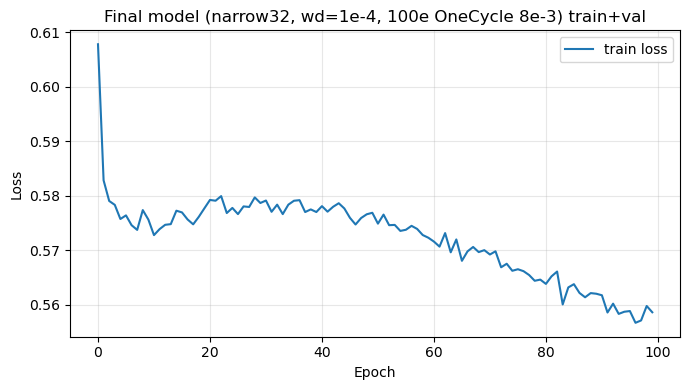


Final model test macro F1 (held-out): 0.7003
Final model parameters: 2,370
Saved: best_model.pth, scaler.joblib


In [ ]:

from joblib import dump

# 1. Combine train + val
X_full = np.vstack([X_train_s, X_val_s])
y_full = np.concatenate([y_train.values, y_val.values]).astype(np.int64)

# 2. Refit scaler on full data
scaler_full = StandardScaler()
X_full_raw = pd.concat([X_train_e, X_val_e], axis=0)
X_full_s = scaler_full.fit_transform(X_full_raw)

# 3. Class weights from full data
counts_full = np.bincount(y_full, minlength=2)
ce_weight_full = torch.tensor(len(y_full) / (2 * counts_full), dtype=torch.float32, device=device)

# 4. Tensors and DataLoader
X_full_t = torch.tensor(X_full_s, dtype=torch.float32, device=device)
y_full_t = torch.tensor(y_full, dtype=torch.long, device=device)
full_loader = DataLoader(TensorDataset(X_full_t, y_full_t), batch_size=32, shuffle=True,
                         generator=torch.Generator().manual_seed(RANDOM_STATE))

# 5. Test loader for final evaluation
X_test_final = torch.tensor(X_test_s, dtype=torch.float32, device=device)
y_test_final = torch.tensor(y_test.values.astype(np.int64), dtype=torch.long, device=device)
test_loader_final = DataLoader(TensorDataset(X_test_final, y_test_final), batch_size=32, shuffle=False)

# 6. Build model
torch.manual_seed(RANDOM_STATE)
final_model = CreditDefaultMLP(INPUT_DIM, hidden_dim=32, dropout=0.2).to(device)
n_final_params = sum(p.numel() for p in final_model.parameters())
print(f"Final model parameters: {n_final_params:,}")

# 7. Train with OneCycleLR
FINAL_EPOCHS = 100
FINAL_MAX_LR = 8e-3
FINAL_PCT_START = 0.25
criterion_full = nn.CrossEntropyLoss(weight=ce_weight_full)
optimizer_full = torch.optim.Adam(
    final_model.parameters(),
    lr=FINAL_MAX_LR / 10.0,
    weight_decay=1e-4,
)
scheduler_full = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_full, max_lr=FINAL_MAX_LR, epochs=FINAL_EPOCHS,
    steps_per_epoch=len(full_loader), pct_start=FINAL_PCT_START,
    div_factor=10.0, final_div_factor=1e4,
)

train_losses_final = []
for epoch in range(1, FINAL_EPOCHS + 1):
    final_model.train()
    epoch_loss, total_n = 0.0, 0
    for xb, yb in full_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_full.zero_grad(set_to_none=True)
        loss = criterion_full(final_model(xb), yb)
        loss.backward()
        optimizer_full.step()
        scheduler_full.step()
        epoch_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)
    train_losses_final.append(epoch_loss / total_n)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train_loss={train_losses_final[-1]:.4f}")

# 8. Plot training curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses_final, label="train loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Final model (narrow32, wd=1e-4, 100e OneCycle 8e-3) train+val")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Evaluate on held-out test set
test_f1_final = calculate_f1_score(final_model, test_loader_final, device)
print(f"\nFinal model test macro F1 (held-out): {test_f1_final:.4f}")
print(f"Final model parameters: {n_final_params:,}")

# 10. Export
torch.save(final_model.state_dict(), "best_model.pth")
dump(scaler_full, "scaler.joblib")
print("Saved: best_model.pth, scaler.joblib")

In [84]:
# Classification report on held-out test set
final_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader_final:
        xb = xb.to(device)
        _, preds = torch.max(final_model(xb), 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(yb.cpu().numpy())

print("Classification Report (held-out test set):\n")
print(classification_report(y_true, y_pred, target_names=["no default (0)", "default (1)"], digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Classification Report (held-out test set):

                precision    recall  f1-score   support

no default (0)     0.8755    0.8425    0.8587      3505
   default (1)     0.5102    0.5779    0.5419       995

      accuracy                         0.7840      4500
     macro avg     0.6928    0.7102    0.7003      4500
  weighted avg     0.7947    0.7840    0.7886      4500

Confusion Matrix:
[[2953  552]
 [ 420  575]]


---
# Part 6: Generalization


**Train vs validation loss:** In the baseline and wider64 model (Experiment 1), train loss kept dropping while validation loss flattened/worsened, a typical overfitting sign. In Experiment 3, dropout reduced this gap. In the final model (Experiment 4b, tuned OneCycle over 100 epochs), train and validation losses stay close and trend down without validation spikes, which is the behavior we want for generalization.

**Validation vs test F1:** In most runs, validation-test macro F1 gaps are small (about 0.005). Test is evaluated only once per experiment, so model choices are not tuned on test.

**Regularization used:**
- **Batch Normalization** in every hidden layer stabilizes optimization and acts as mild regularization.
- **Dropout (0.2)** randomly removes neurons during training, encouraging redundant representations.
- **Weight decay (`1e-4`)** adds L2 regularization and penalizes large weights.
- **OneCycleLR** uses a fixed warmup-then-decay schedule, instead of training until overfitting appears.
- The final model has only **2,370 parameters**, which also reduces overfitting risk.

**Data handling:**
- A stratified 70/15/15 train/val/test split keeps class rates similar across splits.
- All preprocessing (encoding/scaling) is fit on training data only, then applied to val/test (no leakage).
- Class imbalance is handled via balanced class weights in `CrossEntropyLoss`, so the model does not just optimize majority-class accuracy.

**Overall:** The small validation-test gap, combined with regularization and leakage-safe preprocessing, supports that the final model should transfer reasonably well to unseen data.
